In [1]:
import os
import nibabel as nib
import matplotlib.pyplot as plt
#from ipywidgets import interact
import numpy as np
#import ipywidgets as widgets
import pandas as pd
from tqdm import tqdm

/usr/lib/python3/dist-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.17.3 and <1.25.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
#BETTIK_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"
#BETTIK_DIR = "/home/theotime/bettik/"
BETTIK_DIR = "/home/fehrdelt/bettik/"

In [3]:

final_adc_dataset_small_HCP_YA = BETTIK_DIR+"datasets/final_adc_dataset_small/HCP-YA_registered/"
final_adc_dataset_small_Dallas = BETTIK_DIR+"datasets/final_adc_dataset_small/Dallas_registered/"
final_adc_dataset_small_AINI_stroke_ait = BETTIK_DIR+"datasets/final_adc_dataset_small/AIT_final_registered/"
final_adc_dataset_small_isles = BETTIK_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"

final_flair_dataset_small_dallas = BETTIK_DIR+"datasets/final_flair_dataset_small/dallas_registered/"
final_flair_dataset_small_lemon = BETTIK_DIR+"datasets/final_flair_dataset_small/lemon_registered/"
final_flair_dataset_small_isles = BETTIK_DIR+"datasets/final_flair_dataset_small/isles_registered/"

IXI_T1_dataset = BETTIK_DIR+"datasets/dataset_IXI_T1_brain_extraction/"

### Display middle slice of every nifti file in folder

In [4]:
def display_middle_slice_z(folder_path, nb_images, page_number, figsize):
    # List all files in the folder
    files = os.listdir(folder_path)[nb_images*page_number:nb_images*(page_number+1)]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices
    rows = int(np.sqrt(nb_images))
    fig, axes = plt.subplots(rows, rows, figsize=(figsize, figsize))

    for i, nifti_file in enumerate(nifti_files):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        # Get the middle slice index for the z-axis
        middle_slice_z = data.shape[2] // 2

        # Display the middle slice for the z-axis
        axes[i//rows, i%rows].imshow(data[:, :, middle_slice_z], cmap='gray')
        axes[i//rows, i%rows].set_title(f'{i+(page_number*nb_images)}')
        axes[i//rows, i%rows].axis("off")

    # Set the title of the figure
    fig.suptitle('Middle slices of Z-axis for all NIFTI files')
    
    # Show the plot
    plt.show()


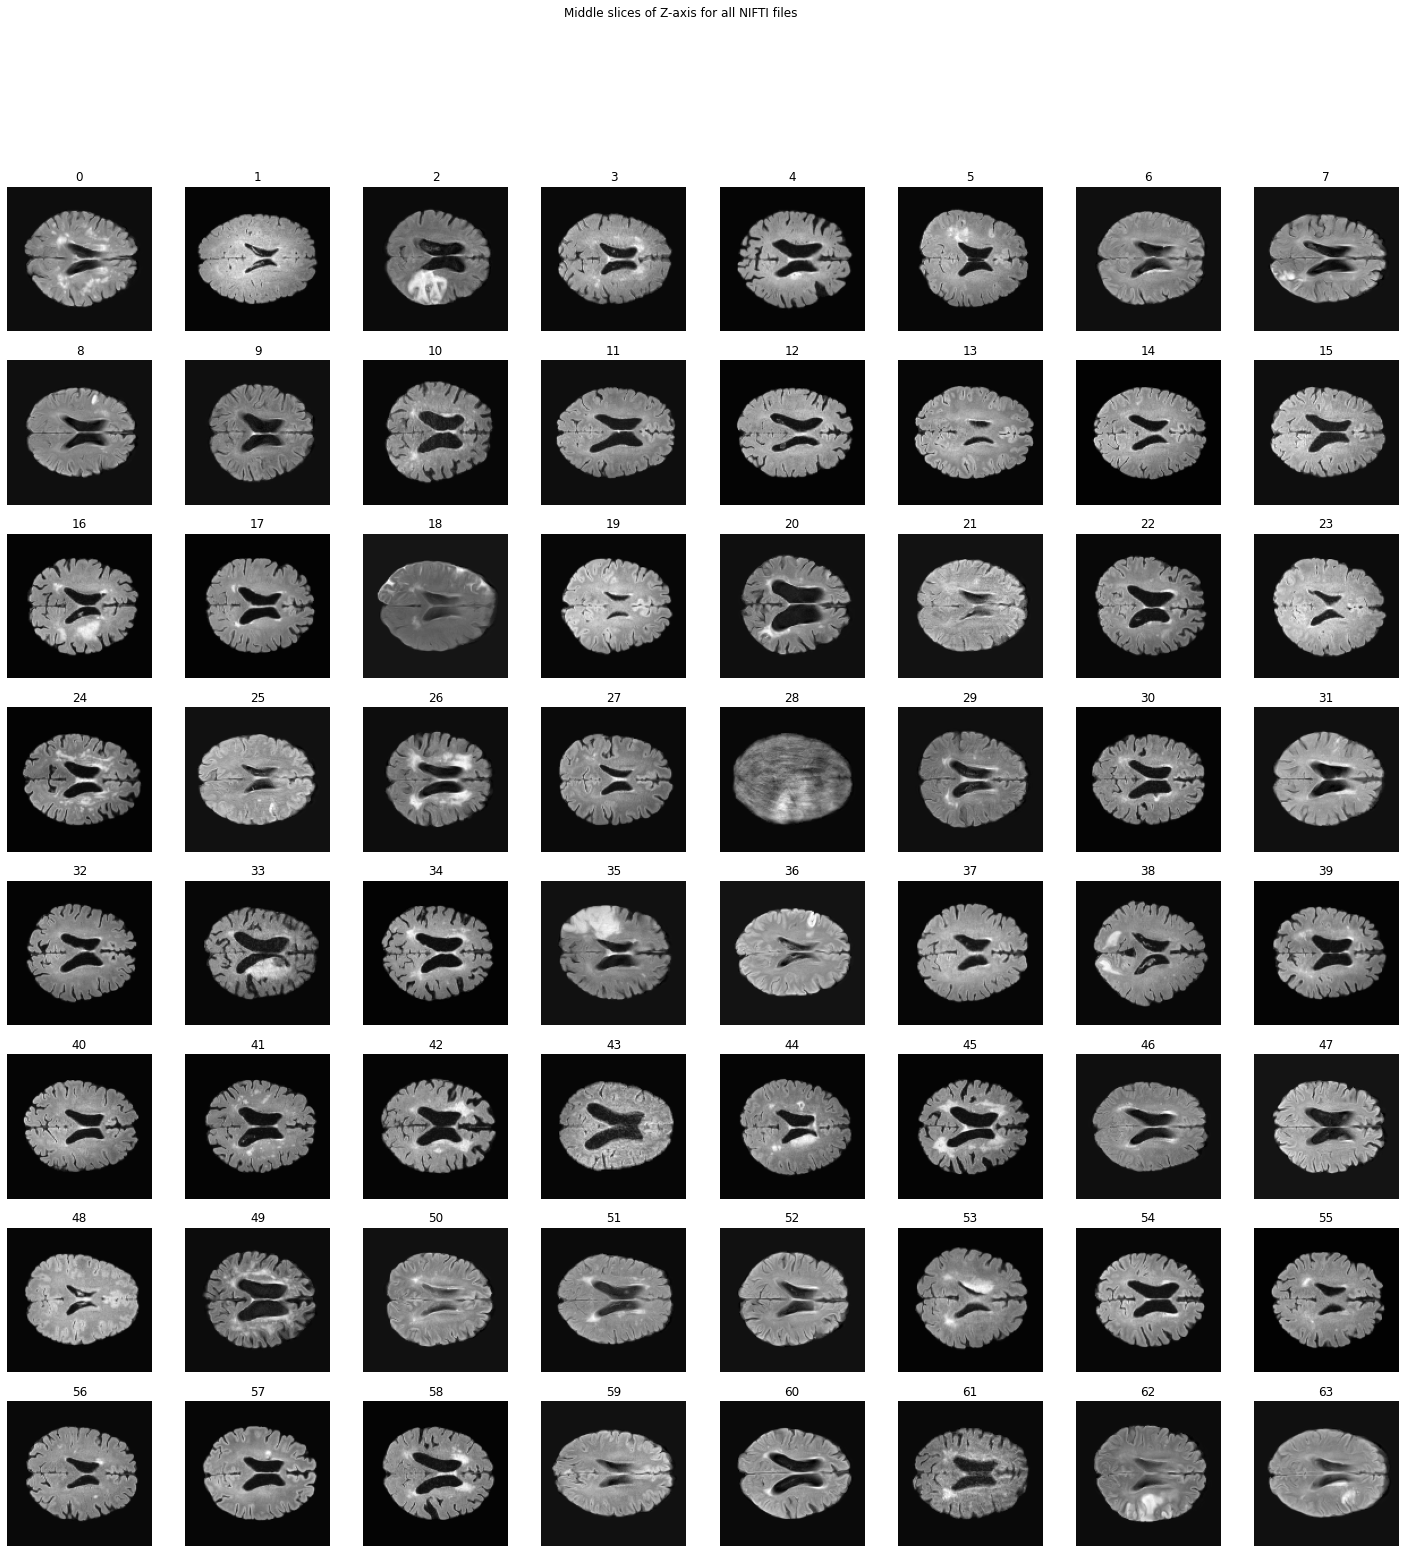

In [31]:
display_middle_slice_z(folder_path=final_flair_dataset_small_isles, nb_images=64, page_number=0, figsize=25)

In [5]:
bad_dallas_flair = [236]
bad_dallas_flair_names = os.listdir(final_flair_dataset_small_dallas)[236]

bad_lemon_flair = [148]
bad_lemon_flair_names = os.listdir(final_flair_dataset_small_lemon)[148]

print("Bad Dallas FLAIR files names:", bad_dallas_flair_names)
print("Bad lemon FLAIR files names:", bad_lemon_flair_names)

Bad Dallas FLAIR files names: sub-4799_ses-wave1_acq-FLAIR_run-1_T2w.nii.gz
Bad lemon FLAIR files names: sub-032360_ses-01_acq-lowres_FLAIR.nii.gz


### Compare histograms from hcp, dallas and aini stroke

In [4]:
bad_files = ["sub-3242_ses-wave2_ADC.nii.gz", 
            "aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz",
            "aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz"]

def display_mean_histogram(folder_path):
    # List all files in the folder
    files = os.listdir(folder_path)

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]
    
    # Create a figure to display all middle slices
    plt.figure(figsize=(10, 10))

    data_sum = []
    skipped_files = 0

    for i, nifti_file in enumerate(tqdm(nifti_files)):
        if nifti_file not in bad_files:
            # Load the NIFTI image
            img_path = os.path.join(folder_path, nifti_file)
            img = nib.load(img_path)
            data = img.get_fdata()
            if len(data_sum) ==0:
                data_sum.append(data.flatten())
            else:
                data_sum[0] += data.flatten()
        else:
            print(f"Skipping bad file: {nifti_file}")
            skipped_files += 1
    
    mean_data = data_sum[0]/(len(nifti_files)-skipped_files)

    # Set the title of the figure
    plt.title(f'Mean histogram of all NIFTI files in {folder_path} (skipped {skipped_files} bad files)')
    plt.hist(mean_data[(mean_data>1) & (mean_data<=3000)], 100)
    # Show the plot
    plt.show()



def display_histograms(folder_path):
    # List all files in the folder
    files = os.listdir(folder_path)[:100]

    # Filter out non-NIFTI files
    nifti_files = [f for f in files if f.endswith('.nii') or f.endswith('.nii.gz')]

    # Create a figure to display all middle slices
    fig, axes = plt.subplots(10, 10, figsize=(50, 50))

    for i, nifti_file in enumerate(tqdm(nifti_files)):
        # Load the NIFTI image
        img_path = os.path.join(folder_path, nifti_file)
        img = nib.load(img_path)
        data = img.get_fdata()

        # Get the middle slice index for the z-axis

        # Display the middle slice for the z-axis
        _, _, _ = axes[i//10, i%10].hist(data.flatten()[data.flatten()>0], 100)
        axes[i//10, i%10].set_title(f'{nifti_file}')

    # Set the title of the figure
    fig.suptitle('Middle slices of Z-axis for all NIFTI files')

    # Show the plot
    plt.show()



100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1015/1015 [03:34<00:00,  4.73it/s]


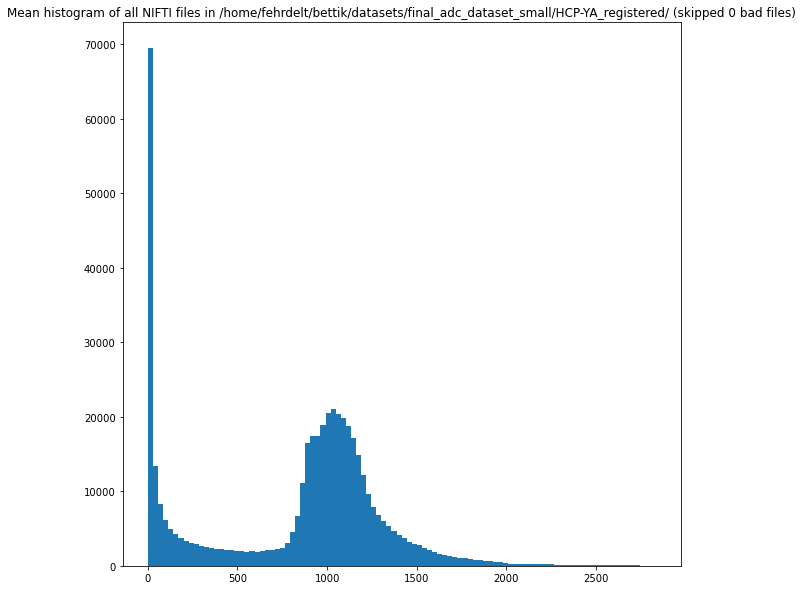

 34%|████████████████████████████████████████████▉                                                                                      | 328/955 [01:33<03:11,  3.28it/s]

Skipping bad file: sub-3242_ses-wave2_ADC.nii.gz


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 955/955 [04:27<00:00,  3.57it/s]


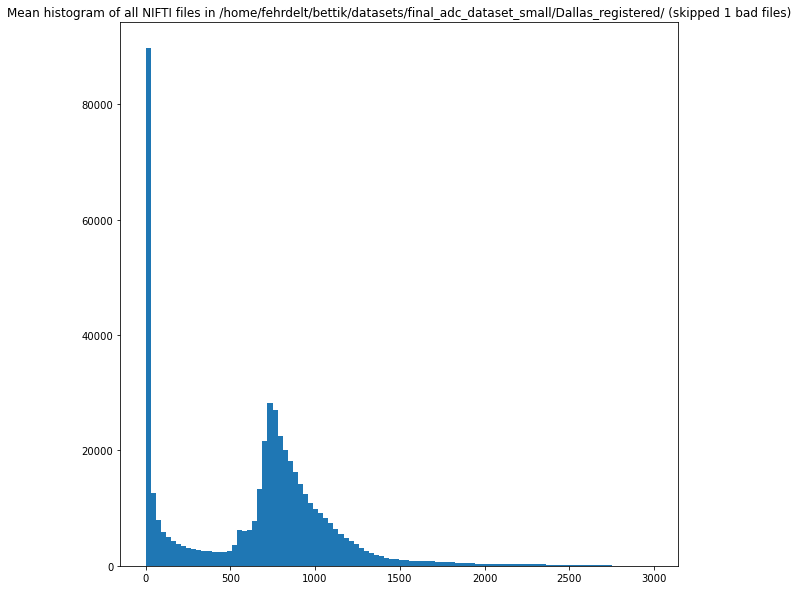

FileNotFoundError: [Errno 2] No such file or directory: '/home/fehrdelt/bettik/datasets/final_adc_dataset_small/AINI-Stroke_AIT_registered/'

In [ ]:
display_mean_histogram(final_adc_dataset_small_HCP_YA)
display_mean_histogram(final_adc_dataset_small_Dallas)


  0%|                                                                                                                                              | 0/75 [00:00<?, ?it/s]

Skipping bad file: aini-stroke-13607_424097_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz


 13%|█████████████████▋                                                                                                                   | 10/75 [00:01<00:09,  7.15it/s]

Skipping bad file: aini-stroke-17579_425560_ADC_HR_DIFF_RESOLVE_3MM_FP_ADC.nii.gz


100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 75/75 [00:14<00:00,  5.18it/s]


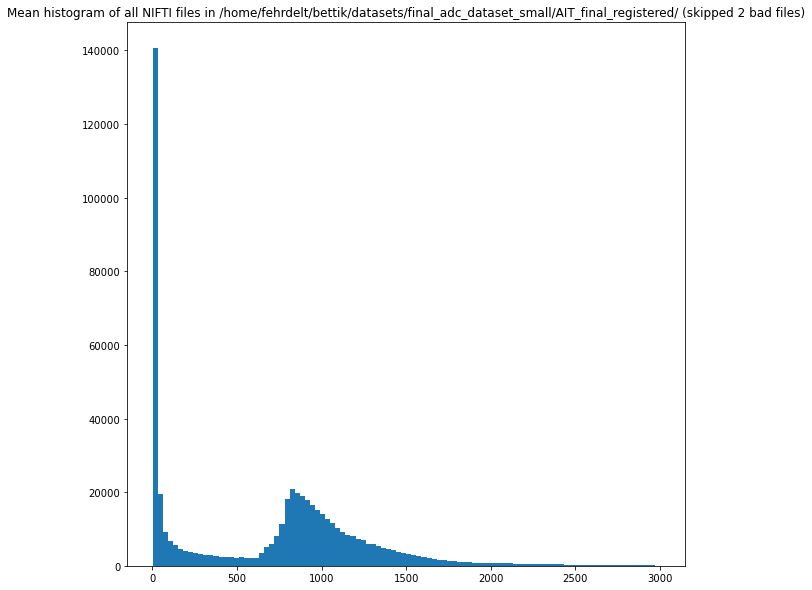

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 250/250 [01:03<00:00,  3.95it/s]


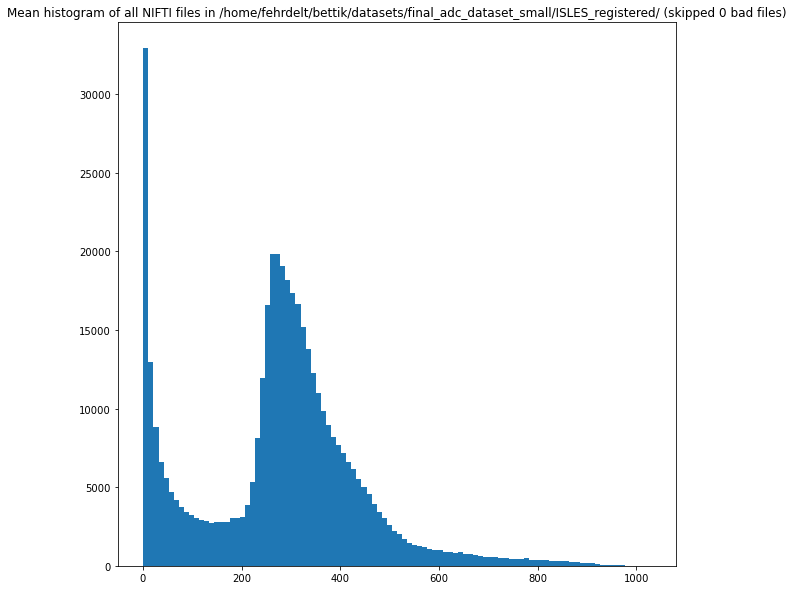

In [8]:
display_mean_histogram(final_adc_dataset_small_AINI_stroke_ait)
display_mean_histogram(final_adc_dataset_small_isles)